In [1]:
from datetime import datetime, timedelta
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [3]:
events = data.get_climate_events()
num_income_groups = 4

In [30]:
bg = con.sql("""
    SELECT *
    FROM block_groups_cbsa
    WHERE CBSA_TYPE = 'Metropolitan'
      AND CBSA_POP_RANK <= 50
""").pl().with_columns(
    pl.col("MEDIAN_HH_INCOME").is_not_null().alias("HAS_INCOME"),
    (pl.col("CBSA_POP_RANK") <= 5).alias("TOP_5")
).with_columns(
    pl.col("MEDIAN_HH_INCOME")
      .qcut(num_income_groups, labels=[str(i) for i in range(1, num_income_groups + 1)], allow_duplicates=True)
      .cast(pl.Utf8)
      .over("CBSAFP")
      .alias("INCOME_DECILE")
)
pbg = bg.to_pandas()
gbg = gpd.GeoDataFrame(
    pbg.drop(columns="geom"),
    geometry=gpd.GeoSeries.from_wkb(pbg["geom"].apply(bytes), crs="EPSG:4269"),
)
bg

GEOID,OGC_FID,STATEFP,COUNTYFP,ALAND,CBSAFP,CSAFP,MEDIAN_HH_INCOME,MEDIAN_HH_INCOME_MOE,geom,CENTROID,CBSA_TITLE,CBSA_TYPE,CSA_TITLE,CBSA_POP_2025,CBSA_POP_RANK,HAS_INCOME,TOP_5,INCOME_DECILE
str,i64,str,str,i64,str,str,f64,f64,binary,binary,str,str,str,i64,i64,bool,bool,str
"""010730111084""",28,"""01""","""073""",892991,"""13820""","""142""",58799.0,4093.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xbb\x00\x00\x00\xff\x03\xacU\xbb\xa9U\xc0\x8a\xcd\xc7\xb5\xa1\xcc@@\xdc-\xc9\x01\xbb\xa9U\xc0$%=\x0c\xad\xcc@@\x8f\xc4\xcb\xd3\xb9\xa9U\xc0r\xdfj\x9d\xb8\xcc@""…","b""\x01\x01\x00\x00\x00\xcaJ\xd1\x95`\xa9U\xc0cH\x89\x8c\xa6\xcc@@""","""Birmingham, AL""","""Metropolitan""","""Birmingham-Cullman-Talladega, …",1197766,48,true,false,"""2"""
"""010730051011""",29,"""01""","""073""",354690,"""13820""","""142""",32115.0,7887.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00+\x00\x00\x00AE\xd5\xaft\xb5U\xc0m\xe7\xfb\xa9\xf1\xbe@@\x89\x0b@\xa3t\xb5U\xc0\xe4h\x8e\xac\xfc\xbe@@\xd0\xd1\xaa\x96t\xb5U\xc0\x17+j0\x0d\xbf@""…","b""\x01\x01\x00\x00\x00\x80\xca\xdc\xe7F\xb5U\xc0\xear-\x9eS\xbf@@""","""Birmingham, AL""","""Metropolitan""","""Birmingham-Cullman-Talladega, …",1197766,48,true,false,"""1"""
"""010730051031""",30,"""01""","""073""",595738,"""13820""","""142""",63417.0,22035.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00?\x00\x00\x00\xc4[\xe7\xdf.\xb5U\xc0\xbe\x13\xb3^\x0c\xbf@@bf\x9f\xc7(\xb5U\xc0\x979]\x16\x13\xbf@@4GV~\x19\xb5U\xc0\x84\x83\xbd\x89!\xbf@""…","b""\x01\x01\x00\x00\x00\xd4\x9f\xb9\xb0\xfb\xb4U\xc0\x09\xef\xc5_~\xbe@@""","""Birmingham, AL""","""Metropolitan""","""Birmingham-Cullman-Talladega, …",1197766,48,true,false,"""2"""
"""010730049022""",31,"""01""","""073""",487114,"""13820""","""142""",47375.0,29815.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00:\x00\x00\x00\x8a\x1e\xf8\x18\xac\xb3U\xc0\xef\xe7\x14\xe4g\xbf@@\x19=\xb7\xd0\x95\xb3U\xc0C\xe4\xf4\xf5|\xbf@@_\x95\x0b\x95\x7f\xb3U\xc0>\x95\xd3\x9e\x92\xbf@""…","b""\x01\x01\x00\x00\x00\x89S\xb7\xa1f\xb3U\xc0e\x17\xb9\xa3I\xbf@@""","""Birmingham, AL""","""Metropolitan""","""Birmingham-Cullman-Talladega, …",1197766,48,true,false,"""1"""
"""010730129131""",32,"""01""","""073""",933658,"""13820""","""142""",110989.0,105318.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00p\x00\x00\x00]\x8b\x16\xa0m\xb3U\xc0\xdc\xd7\x81sF\xb0@@n\x85\xb0\x1aK\xb3U\xc0[\x09\xdd%q\xb0@@p\x07\xea\x94G\xb3U\xc0\xca\xe0(yu\xb0@""…","b""\x01\x01\x00\x00\x00\xd5\xbd*s\xf1\xb2U\xc0\xc7\xba\xaa;@\xb0@@""","""Birmingham, AL""","""Metropolitan""","""Birmingham-Cullman-Talladega, …",1197766,48,true,false,"""4"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""361031456042""",11676,"""36""","""103""",403883,"""35620""","""408""",null,null,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00*\x00\x00\x00\xad\x85Yh\xe7PR\xc0\x14\xed*\xa4\xfcdD@\xc1;\xf9\xf4\xd8PR\xc0U\xdc\xb8\xc5\xfcdD@\xa5gz\x89\xb1PR\xc0\xd8\xba\xd4\x08\xfddD""…","b""\x01\x01\x00\x00\x00C\xd8\xbe\x88\x7fPR\xc0\xc3:\xc5\x17\xc1dD@""","""New York-Newark-Jersey City, N…","""Metropolitan""","""New York-Newark, NY-NJ-CT-PA""",20112448,1,false,true,null
"""361031461053""",12547,"""36""","""103""",949756,"""35620""","""408""",null,null,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x008\x00\x00\x00\x89{,}\xe8NR\xc0\xb0\x20\xcdX4aD@xD\x85\xea\xe6NR\xc0\x1f,cC7aD@=Fy\xe6\xe5NR\xc0\x0b%\x93S;aD""…","b""\x01\x01\x00\x00\x00\x94Q\xd8\xfa\x9fNR\xc0\x1f\xd0\x15\xd0\x82aD@""","""New York-Newark-Jersey City, N…","""Metropolitan""","""New York-Newark, NY-NJ-CT-PA""",20112448,1,false,true,null
"""361031457022""",13170,"""36""","""103""",777768,"""35620""","""408""",null,null,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x19\x00\x00\x00(D\xc0!TOR\xc0\xf0\x88\x0a\xd5\xcdeD@\xf4j\x80\xd2POR\xc0\x86\xe2\x8e7\xf9eD@\xd3\x16\xd7\xf8LOR\xc0\x98\x196\xca\xfaeD""…","b""\x01\x01\x00\x00\x00/)\x1e\x08\xe2NR\xc0\x90Iv>\xbeeD@""","""New York-Newark-Jersey City, N…","""Metropolitan""","""New York-Newark, NY-NJ-CT-PA""",20112448,1,false,true,null


## CBSA map plots

In [57]:
cbsafps = bg["CBSAFP"].unique().to_list()
N = len(cbsafps)

fig_root = root / "figures" / "cbas"
fig_root.mkdir(parents=True, exist_ok=True)

for i in tqdm(range(N)):
    cbsafp = cbsafps[i]
    fig_path = fig_root / f"{cbsafp}.png"
    
    fig, ax = plt.subplots()
    df = gbg.loc[gbg["CBSAFP"] == cbsafp]
    title = df["CSA_TITLE"].iloc[0]
    df.boundary.plot(
        color="#444", 
        linewidth=0.4,
        ax=ax
    )
    cx.add_basemap(ax=ax, zoom='auto', crs="EPSG:4269")
    ax.set_title(title)
    ax.set_axis_off()
    fig.savefig(fig_path, dpi=200)

    plt.close()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:14<00:00,  3.47it/s]


In [58]:
cbsafps = bg["CBSAFP"].unique().to_list()
N = len(cbsafps)

fig_root = root / "figures" / "cbas" / "has-income"
fig_root.mkdir(parents=True, exist_ok=True)

for i in tqdm(range(N)):
    cbsafp = cbsafps[i]
    fig_path = fig_root / f"{cbsafp}.png"
    
    fig, ax = plt.subplots()
    df = gbg.loc[gbg["CBSAFP"] == cbsafp]
    title = df["CSA_TITLE"].iloc[0]
    df.plot(
        column="HAS_INCOME",
        categorical=True,
        cmap="coolwarm",
        alpha=0.3,
        edgecolor="black",
        linewidth=0.2,
        legend=False,
        #legend=True,
        #legend_kwds={"title": "Has median HH income", "loc": "lower right"},
        ax=ax
    )
    cx.add_basemap(ax=ax, zoom='auto', crs="EPSG:4269")
    ax.set_title(title)
    ax.set_axis_off()
    fig.savefig(fig_path, dpi=200)

    plt.close()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:18<00:00,  2.70it/s]


In [59]:
cbsafps = bg["CBSAFP"].unique().to_list()
N = len(cbsafps)

fig_root = root / "figures" / "cbas" / "income-deciles"
fig_root.mkdir(parents=True, exist_ok=True)

for i in tqdm(range(N)):
    cbsafp = cbsafps[i]
    fig_path = fig_root / f"{cbsafp}.png"
    
    fig, ax = plt.subplots()
    df = gbg.loc[gbg["CBSAFP"] == cbsafp]
    title = df["CSA_TITLE"].iloc[0]
    df.plot(
        column="INCOME_DECILE",
        categorical=True,
        cmap="viridis",
        alpha=0.7,
        edgecolor="white",
        linewidth=0.15,
        legend=False,
        #legend=True,
        #legend_kwds={"title": "Income decile", "loc": "upper right"},
        missing_kwds={"color": "lightgray", "label": "No data"},
        ax=ax
    )
    cx.add_basemap(ax=ax, zoom='auto', crs="EPSG:4269")
    ax.set_title(title)
    ax.set_axis_off()
    fig.savefig(fig_path, dpi=200)

    plt.close()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:21<00:00,  2.33it/s]


## Gyration of CBSAs

In [107]:
visits = con.sql("""
    SELECT 
        DATE_RANGE_START, HOME_GEOID, 
        SUM(VISITOR_COUNTS) AS VISITOR_COUNTS,
        SUM(DIST * VISITOR_COUNTS) / SUM(VISITOR_COUNTS) AS AVG_DIST
    FROM block_group_visit_dist
    GROUP BY 1, 2
""").pl().join(bg, left_on="HOME_GEOID", right_on="GEOID")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [108]:
heatwave_date = events[0]["date"]
closest_date = visits.filter(pl.col("DATE_RANGE_START") <= heatwave_date)["DATE_RANGE_START"].max()
minus_three_weeks = heatwave_date - timedelta(days=3*7)
baseline_visits = visits.filter(
    (pl.col("DATE_RANGE_START") >= minus_three_weeks) & (pl.col("DATE_RANGE_START") <= heatwave_date))
baseline_agg = baseline_visits.group_by("CSAFP").agg(
    pl.col("VISITOR_COUNTS").mean().alias("VISITOR_COUNTS_BASELINE"),
    pl.col("AVG_DIST").mean().alias("AVG_DIST_BASELINE"),
)

In [109]:
visits = visits.join(baseline_agg, on="CSAFP").with_columns(
    (pl.col("VISITOR_COUNTS") / pl.col("VISITOR_COUNTS_BASELINE")).alias("VISITOR_COUNTS_NORMALIZED"),
    (pl.col("AVG_DIST") / pl.col("AVG_DIST_BASELINE")).alias("AVG_DIST_NORMALIZED")
)

In [116]:
group

DATE_RANGE_START,CSAFP,CSA_TITLE,TOP_5,VISITOR_COUNTS,AVG_DIST
datetime[μs],str,str,bool,"decimal[38,0]",f64
2025-11-10 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,116757664,45786.244327
2025-03-31 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,117919645,NaN
2025-12-01 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,113289177,36029.386618
2025-03-24 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,114598063,49557.312737
2025-02-03 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,111860365,39992.889514
…,…,…,…,…,…
2025-10-27 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,113798586,52359.032828
2025-08-25 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,116871024,62606.450074
2025-11-17 00:00:00,"""428""","""Philadelphia-Reading-Camden, P…",false,114617640,47176.445896


ValueError: Could not interpret value `VISITOR_COUNTS_NORMALIZED` for `y`. An entry with this name does not appear in `data`.

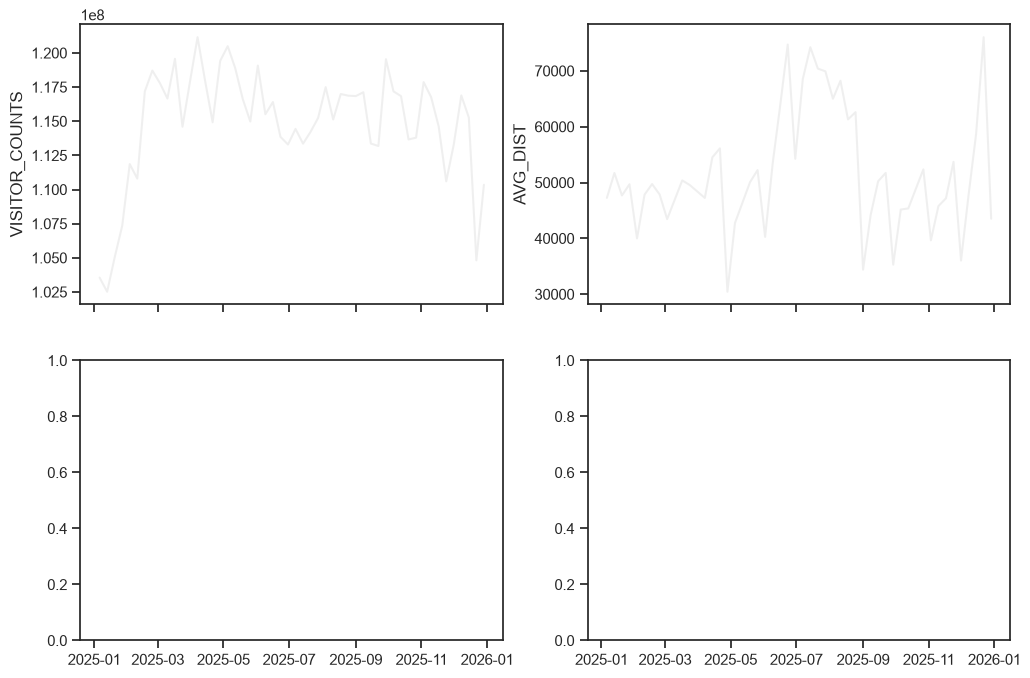

In [115]:
agg = visits.group_by("DATE_RANGE_START", "CSAFP", "CSA_TITLE", "TOP_5").agg(
    pl.col("VISITOR_COUNTS").sum(),
    ((pl.col("AVG_DIST") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("AVG_DIST")
)
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(12,8))
kwarg_map = {
    True: {
        "alpha": 1,
    },
    False: {
        "alpha": 0.3,
        "color": "#ccc"
    }
}
for (label, top_5), group in agg.sort("TOP_5").group_by("CSA_TITLE", "TOP_5", maintain_order=True):
    kwargs = kwarg_map[top_5]
    sns.lineplot(group, x="DATE_RANGE_START", y="VISITOR_COUNTS", ax=axes[0][0], **kwargs)
    sns.lineplot(group, x="DATE_RANGE_START", y="AVG_DIST", ax=axes[0][1], **kwargs)

    sns.lineplot(group, x="DATE_RANGE_START", y="VISITOR_COUNTS_NORMALIZED", ax=axes[1][0], **kwargs)
    sns.lineplot(group, x="DATE_RANGE_START", y="AVG_DIST_NORMALIZED", ax=axes[1][1], **kwargs)

for event in events:
    for ax in axes.flatten():
        ax.axvline(event["date"], color="#666", linestyle="--")

fig.tight_layout()

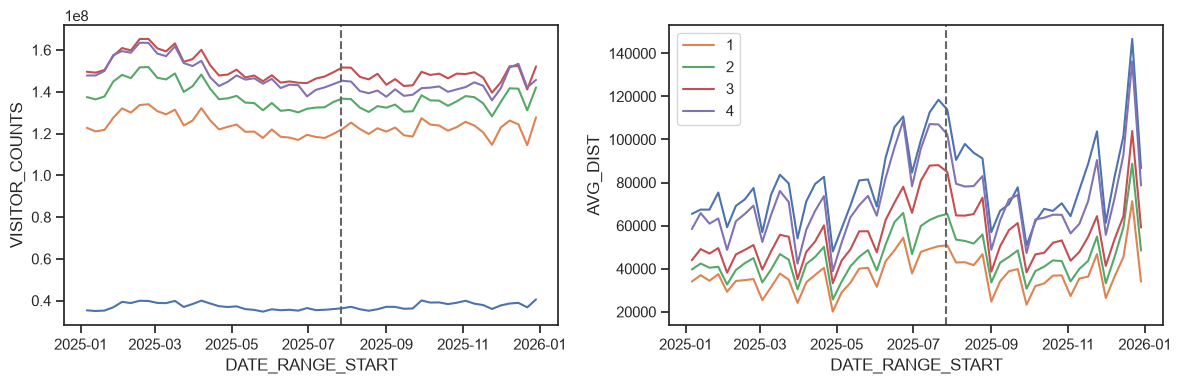

In [88]:
agg = visits.filter(pl.col("STATEFP") == '12').group_by("DATE_RANGE_START", "INCOME_DECILE").agg(
    pl.col("VISITOR_COUNTS").sum(),
    ((pl.col("AVG_DIST") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("AVG_DIST")
)

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(12,4))
for (label, ), group in agg.sort("INCOME_DECILE").group_by("INCOME_DECILE", maintain_order=True):
    sns.lineplot(group, x="DATE_RANGE_START", y="VISITOR_COUNTS", ax=axes[0], label=label, legend=False)
    sns.lineplot(group, x="DATE_RANGE_START", y="AVG_DIST", ax=axes[1], label=label, legend=True)

for event in events:
    for ax in axes.flatten():
        ax.axvline(event["date"], color="#666", linestyle="--")

fig.tight_layout()

In [91]:
baseline_agg

CSAFP,VISITOR_COUNTS_BASELINE,AVG_DIST_BASELINE
str,f64,f64
null,40774.068356,81371.262092
"""376""",20924.904726,61000.867861
"""348""",25369.690605,63971.755531
"""266""",31478.094374,59328.980477
"""350""",33827.834785,50985.687188
…,…,…
"""206""",53188.251869,75426.139768
"""472""",23540.431862,84293.973212
"""142""",44755.652952,38835.770595
